In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("Dataset/spam.csv",encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model Building
# 5. Evaluation
# 6. Website
# 7. Deploy

## 1. Data Cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
# drop last 3 cols
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace=True)
df.sample(5)

,v1,v2
2772,ham,Still in customer place
2665,ham,R u meeting da ge at nite tmr?
2130,ham,Later i guess. I needa do mcat study too.
1100,ham,You busy or can I come by at some point and fi...
1833,ham,When should I come over?


In [6]:
# renaming the cols
df.rename(columns={"v1":"target","v2":"text"},inplace=True)
df.sample(5)

,target,text
423,spam,URGENT! Your Mobile number has been awarded wi...
5330,ham,Dude im no longer a pisces. Im an aquarius now.
1908,ham,Hello beautiful r u ok? I've kinda ad a row wi...
3013,ham,I might go 2 sch. Yar at e salon now v boring.
2522,ham,Dunno lei... I might b eatin wif my frens... I...


In [7]:
df.shape

(5572, 2)

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()

In [9]:
df['target']=encoder.fit_transform(df['target']) # ham:0, spam:1

In [10]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
# check if missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [12]:
# check for duplicate values
df.duplicated().sum()

403

In [13]:
df=df.drop_duplicates(keep='first')

In [14]:
df.duplicated().sum()

0

In [15]:
df.shape

(5169, 2)

## 2.EDA: Data Understanding/Analysis

In [16]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

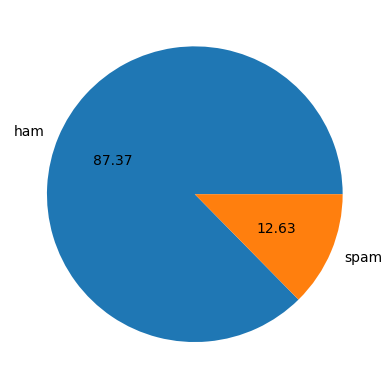

In [18]:
# To find distribution of spam and ham sms in the dataset: here inference is imbalanced dataset
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [47]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [48]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ramesh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# 3 more fxs: 1) no_chs 2) no_wks 3) no_sentences
# nltk, punkt: sentence tokenizer (for words and sentences)

In [20]:
df["num_characters"]=df["text"].apply(len)
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [21]:
df["num_words"]=df["text"].apply(lambda x:len(nltk.word_tokenize(x)))
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [22]:
df["num_sentences"]=df["text"].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [23]:
df[["num_characters","num_words","num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [24]:
# ham message analysis
df[df["target"]==0][["num_characters","num_words","num_sentences"]].describe() # pass the next args as a list

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [25]:
# spam message analysis
df[df["target"]==1][["num_characters","num_words","num_sentences"]].describe() # pass the next args as a list

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [26]:
# viz: plotting histogram for both the classes(spam & ham)
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

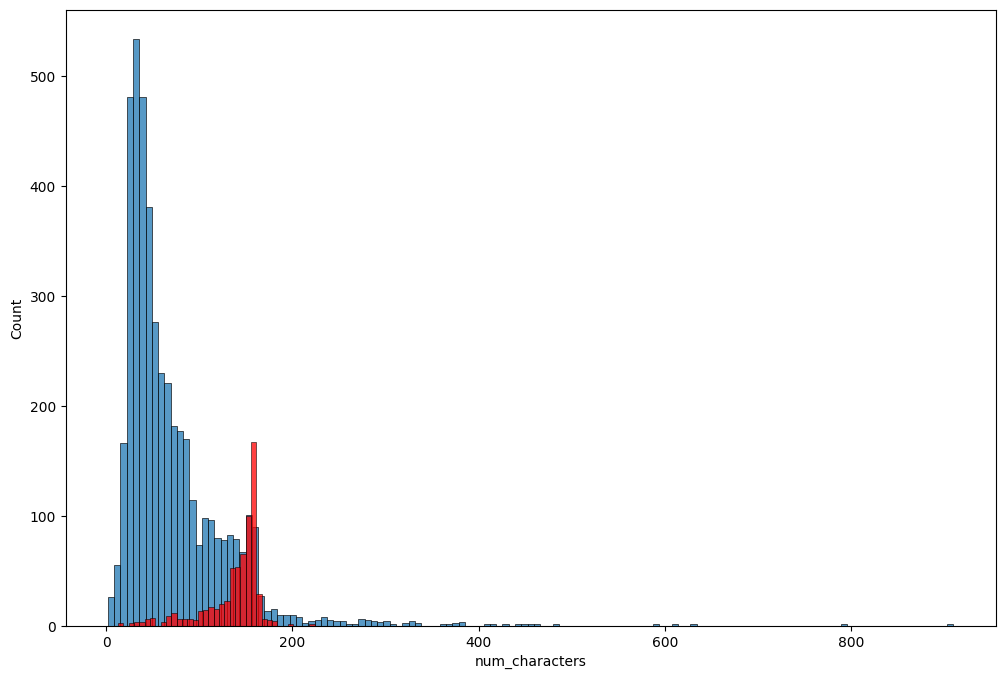

In [27]:
plt.figure(figsize=(12,8))
sns.histplot(df[df["target"]==0]["num_characters"])
sns.histplot(df[df["target"]==1]["num_characters"], color="red")

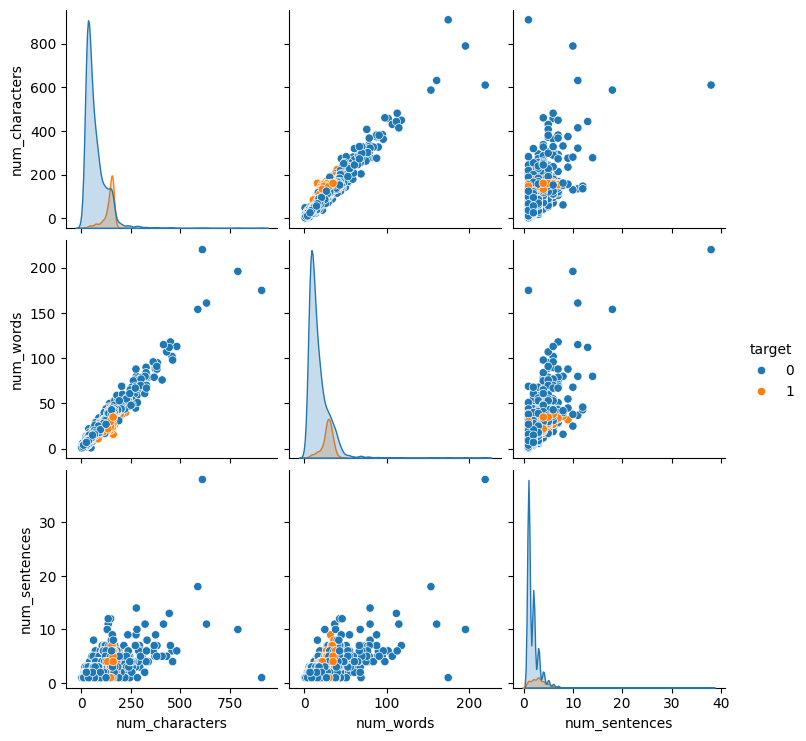

In [28]:
sns.pairplot(df,hue="target") # to find co relation between fxs

In [ ]:
# data has outliers: which can lead to bad analysis, so make it normalized
# so we can check correlation

<Axes: >

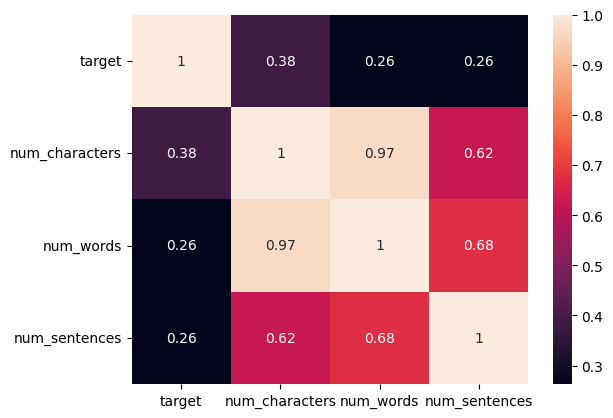

In [29]:
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True)


In [30]:
# find the top words used in ham and spam

## 3. Data/Text Preprocessing
* Convert text to Lower case
* Tokenization
* Removing special characters
* Removing stop words and puntuations: used to construct a sentence but doesn't contribute any meaning in the sentence
* Stemming/Lemmitization: Meaning will be same but removing redundant words 

In [53]:
# Removing stop words and puntuations
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ramesh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [55]:
stopwords.words("english")

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [56]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
# for stemming, use nltk lib
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem("loving") # converts to its root form

'love'

In [ ]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text=y[:] # clone it, because list is mutable dt and points to same reference
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [66]:
transform_text("Did you like my presentation on ml")

'like present ml'

In [67]:
transform_text(df["text"][10])

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [71]:
df['transformed_text']=df['text'].apply(transform_text)

In [83]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [72]:
# world cloud: TF which words are used max in spam and ham, makes the important word look bigger in size, sim to bubble viz
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [75]:
import sys
!{sys.executable} -m pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
from wordcloud import WordCloud

In [84]:
wc=WordCloud(width=50,height=50,min_font_size=10,background_color='white')

In [85]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

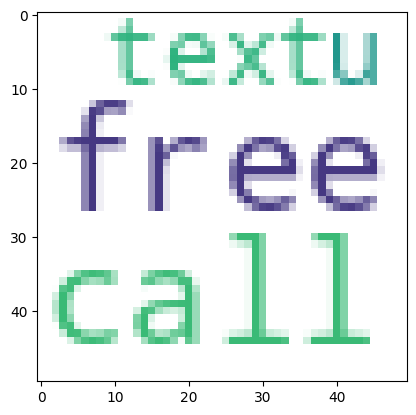

In [86]:
plt.imshow(spam_wc)

In [87]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

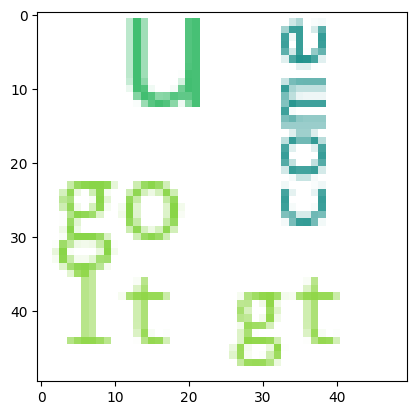

In [88]:
plt.imshow(ham_wc)

In [ ]:
# from wordcloud, also using custom code TF top 30 words mostly used in spam and ham

In [90]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [91]:
len(spam_corpus)

9939

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'call'),
  Text(1, 0, 'free'),
  Text(2, 0, '2'),
  Text(3, 0, 'txt'),
  Text(4, 0, 'text'),
  Text(5, 0, 'u'),
  Text(6, 0, 'ur'),
  Text(7, 0, 'mobil'),
  Text(8, 0, 'stop'),
  Text(9, 0, 'repli'),
  Text(10, 0, 'claim'),
  Text(11, 0, '4'),
  Text(12, 0, 'prize'),
  Text(13, 0, 'get'),
  Text(14, 0, 'new'),
  Text(15, 0, 'servic'),
  Text(16, 0, 'tone'),
  Text(17, 0, 'send'),
  Text(18, 0, 'urgent'),
  Text(19, 0, 'nokia'),
  Text(20, 0, 'contact'),
  Text(21, 0, 'award'),
  Text(22, 0, 'phone'),
  Text(23, 0, 'cash'),
  Text(24, 0, 'pleas'),
  Text(25, 0, 'week'),
  Text(26, 0, 'win'),
  Text(27, 0, 'c'),
  Text(28, 0, 'collect'),
  Text(29, 0, 'min')])

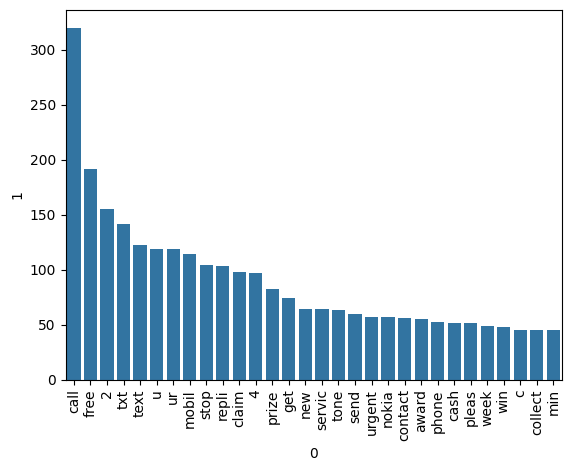

In [108]:
from collections import Counter
import seaborn as sns

data = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=data[0], y=data[1])
plt.xticks(rotation=90)

In [109]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'u'),
  Text(1, 0, 'go'),
  Text(2, 0, 'get'),
  Text(3, 0, 'gt'),
  Text(4, 0, 'lt'),
  Text(5, 0, '2'),
  Text(6, 0, 'come'),
  Text(7, 0, 'got'),
  Text(8, 0, 'know'),
  Text(9, 0, 'like'),
  Text(10, 0, 'call'),
  Text(11, 0, 'time'),
  Text(12, 0, 'ok'),
  Text(13, 0, 'love'),
  Text(14, 0, 'good'),
  Text(15, 0, 'want'),
  Text(16, 0, 'ur'),
  Text(17, 0, 'day'),
  Text(18, 0, 'need'),
  Text(19, 0, 'one'),
  Text(20, 0, 'lor'),
  Text(21, 0, '4'),
  Text(22, 0, 'home'),
  Text(23, 0, 'think'),
  Text(24, 0, 'see'),
  Text(25, 0, 'take'),
  Text(26, 0, 'still'),
  Text(27, 0, 'da'),
  Text(28, 0, 'tell'),
  Text(29, 0, 'make')])

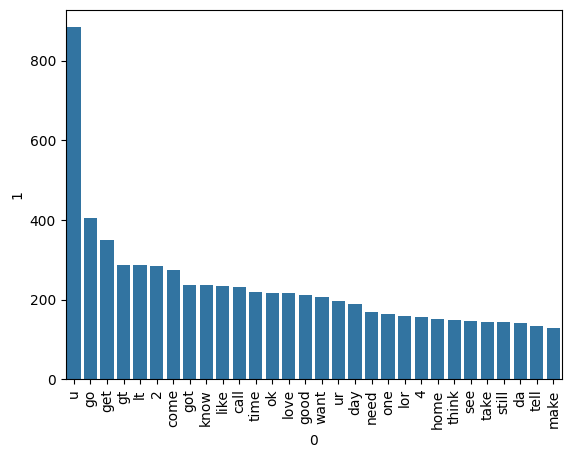

In [110]:
from collections import Counter
import seaborn as sns

data = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=data[0], y=data[1])
plt.xticks(rotation=90)

## Model Building, Predictive Analysis

In [165]:
# Best is NaiveBaise Algo, all algo requires numerical input
# Convert text to vector, cld as vectorization: m: BagOfWords(CV), TFIDF, Word2Vec, etc.

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer 
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)



In [166]:
X=tfidf.fit_transform(df['transformed_text']).toarray()

In [167]:
X.shape

(5169, 3000)

In [168]:
y=df['target'].values

In [169]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [170]:
from sklearn.model_selection import train_test_split

In [171]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [172]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [173]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,BaggingClassifier,ExtraTreesClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [174]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt=GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb=XGBClassifier(n_estimators=50,random_state=2)

In [175]:
clfs={
    'SVC':svc,
    'KN':knc,
    'NB':mnb,
    'DT':dtc,
    'LR':lrc,
    'RF':rfc,
    'AdaBoost':abc,
    'BgC':bc,
    'ETC':etc, # more random than RF
    
}

In [176]:
def train_clf(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred=clf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    return accuracy,precision

In [177]:
train_clf(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [178]:
accuracy_scores=[]
precision_scores=[]
for name,clf in clfs.items():
    current_accuracy,current_precision=train_clf(clf,X_train,y_train,X_test,y_test)
    print("For:",name)
    print("Accuracy:",current_accuracy)
    print("Precision:",current_precision)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For: SVC
Accuracy: 0.9758220502901354
Precision: 0.9747899159663865
For: KN
Accuracy: 0.9052224371373307
Precision: 1.0
For: NB
Accuracy: 0.9709864603481625
Precision: 1.0
For: DT
Accuracy: 0.9303675048355899
Precision: 0.8173076923076923
For: LR
Accuracy: 0.9584139264990329
Precision: 0.9702970297029703
For: RF
Accuracy: 0.9758220502901354
Precision: 0.9829059829059829
For: AdaBoost
Accuracy: 0.960348162475822
Precision: 0.9292035398230089
For: BgC
Accuracy: 0.9584139264990329
Precision: 0.8682170542635659
For: ETC
Accuracy: 0.9748549323017408
Precision: 0.9745762711864406


In [159]:
performance_df=pd.DataFrame({
        'Algorithm':clfs.keys(),
        'Accuracy':accuracy_scores,
        'Precision':precision_scores
        }).sort_values(by=['Accuracy', 'Precision'], ascending=[False, False])

In [160]:
performance_df

,Algorithm,Accuracy,Precision
8,ETC,0.972921,0.982456
0,SVC,0.972921,0.974138
5,RF,0.971954,1.000000
6,AdaBoost,0.961315,0.945455
2,NB,0.959381,1.000000
7,BgC,0.958414,0.862595
4,LR,0.951644,0.940000
3,DT,0.935203,0.838095
1,KN,0.900387,1.000000


In [163]:
performance_df1=pd.melt(performance_df,id_vars="Algorithm")

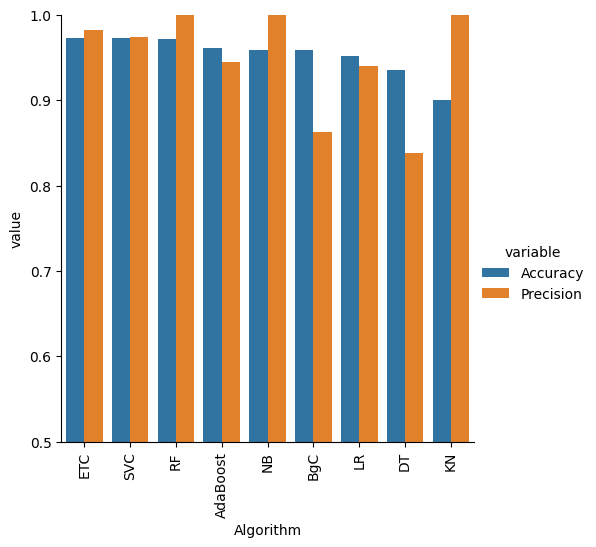

In [164]:
sns.catplot(x='Algorithm',y='value',hue='variable',data=performance_df1,kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [137]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test,y_pred1)}")
print(f"Precission: {precision_score(y_test,y_pred1)}")
print(f"Confusion Matrix: \n{confusion_matrix(y_test,y_pred1)}")

Accuracy: 0.8762088974854932
Precission: 0.5231481481481481
Confusion Matrix: 
[[793 103]
 [ 25 113]]


In [191]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test,y_pred2)}")
print(f"Precission: {precision_score(y_test,y_pred2)}")
print(f"Confusion Matrix: \n{confusion_matrix(y_test,y_pred2)}")

Accuracy: 0.9709864603481625
Precission: 1.0
Confusion Matrix: 
[[896   0]
 [ 30 108]]


In [139]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test,y_pred3)}")
print(f"Precission: {precision_score(y_test,y_pred3)}")
print(f"Confusion Matrix: \n{confusion_matrix(y_test,y_pred3)}")

Accuracy: 0.9700193423597679
Precission: 0.9734513274336283
Confusion Matrix: 
[[893   3]
 [ 28 110]]


In [ ]:
# when data is imbalanced, precision metrics is considered


In [141]:
# tfidf---> MNB best performed

In [ ]:
# model improve
# 1. change the max_features param: for how many words vectorization is performed (a hidden param) of TFIDF
# only vectorize the 1000 most commonly used words, and not by defautl all 6000 unique words

In [180]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [181]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [183]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [184]:

new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [185]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [186]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,ETC,0.972921,0.982456,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576
1,SVC,0.972921,0.974138,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790
2,RF,0.971954,1.000000,0.975822,0.982906,0.975822,0.982906,0.975822,0.982906
3,AdaBoost,0.961315,0.945455,0.960348,0.929204,0.960348,0.929204,0.960348,0.929204
4,NB,0.959381,1.000000,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000
5,BgC,0.958414,0.862595,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217
6,LR,0.951644,0.940000,0.958414,0.970297,0.958414,0.970297,0.958414,0.970297
7,DT,0.935203,0.838095,0.930368,0.817308,0.930368,0.817308,0.930368,0.817308
8,KN,0.900387,1.000000,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000


In [187]:

# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [192]:

import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

In [193]:
!pip freeze > requirements.txt